In [1]:
import sys
import os

import numpy as np
import random

import torch
import torch.nn as nn
from torchinfo import summary
from torchvision.transforms import transforms
from torchvision.datasets import DatasetFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.optim as optim

import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np 
from collections import Counter

BASE_FOLDER = os.path.dirname(os.getcwd())
sys.path.append(BASE_FOLDER)

from src.models import *
from src.utils import *

In [2]:
def init(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
init()

In [4]:
DATASET_FOLDER = os.path.join(BASE_FOLDER, "data", "105_classes_pins_dataset")
MODEL_NAME = "recognitionv2"
CHECKPOINTS_FOLDER = os.path.join(BASE_FOLDER, "checkpoints", MODEL_NAME)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
ds = dict()

for name in os.listdir(DATASET_FOLDER):
    if name not in ds:
        ds[name] = []
    
    folder = os.path.join(DATASET_FOLDER, name)
     
    for f in os.listdir(folder):
        ds[name].append(f)

for i ,(k, v) in enumerate(ds.items()):
    print(f"class: {k} | images: {len(v)}")
    if(i == 5): break
        

class: Gia Huy | images: 92
class: Huu Quang | images: 86
class: pins_Adriana Lima | images: 213
class: pins_Alex Lawther | images: 152
class: pins_Alexandra Daddario | images: 225
class: pins_Alvaro Morte | images: 139


In [6]:
# min_h, max_h = 1e6, 0
# min_w, max_w = 1e6, 0

# for k, v in ds.items():
#     for name in v:
#         path = os.path.join(DATASET_FOLDER, k, name)
#         with Image.open(path) as img:
#             w, h = img.size  

#             if h < min_h:
#                 min_h = h
#             if h > max_h:
#                 max_h = h

#             if w < min_w:
#                 min_w = w
#             if w > max_w:
#                 max_w = w

# print(f"Height: Min={min_h}, Max={max_h}")
# print(f"Width:  Min={min_w}, Max={max_w}")

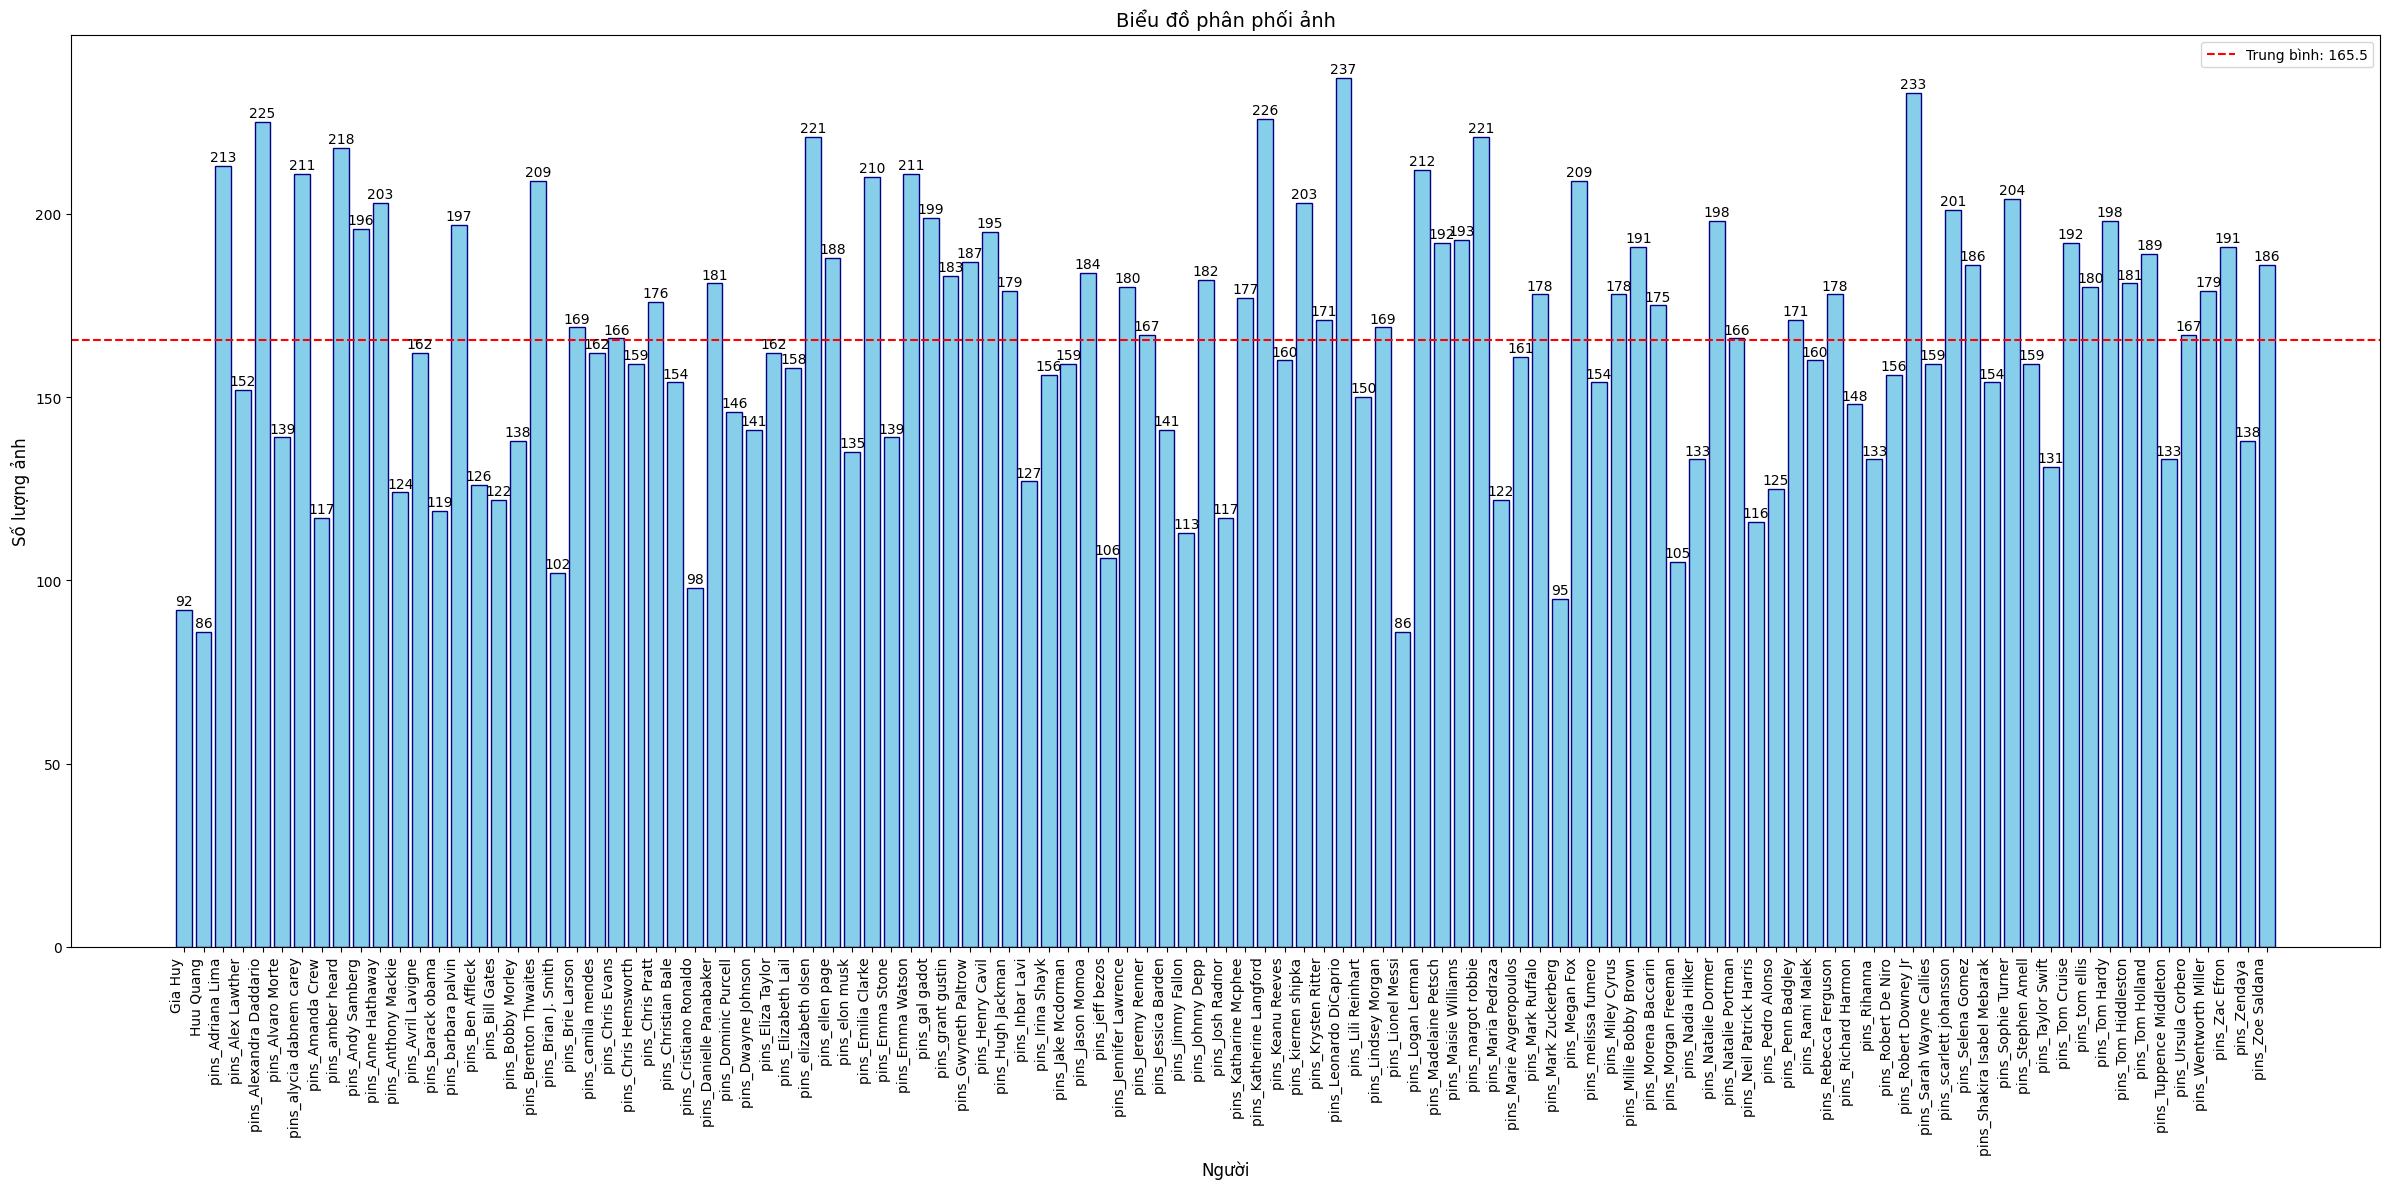

In [7]:
names = list(ds.keys())
counts = [len(files) for files in ds.values()]

plt.figure(figsize=(24, 12))
bars = plt.bar(names, counts, color="skyblue", edgecolor="navy")

plt.xlabel("Người", fontsize=12)
plt.ylabel("Số lượng ảnh", fontsize=12)
plt.title("Biểu đồ phân phối ảnh", fontsize=14)
plt.xticks(rotation=90, ha="right")

avg = sum(counts) / len(counts)
plt.axhline(avg, color="red", linestyle="--", label=f"Trung bình: {avg:.1f}")
plt.legend()

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, yval + 0.5, yval, ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

In [8]:
print(f"Phương sai: {np.var(counts):.2f}")
print(f"Độ lệch chuẩn: {np.std(counts):.2f}")

Phương sai: 1243.86
Độ lệch chuẩn: 35.27


In [9]:
class_names = sorted(ds.keys())
class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}

In [10]:
class_to_idx 

{'Gia Huy': 0,
 'Huu Quang': 1,
 'pins_Adriana Lima': 2,
 'pins_Alex Lawther': 3,
 'pins_Alexandra Daddario': 4,
 'pins_Alvaro Morte': 5,
 'pins_Amanda Crew': 6,
 'pins_Andy Samberg': 7,
 'pins_Anne Hathaway': 8,
 'pins_Anthony Mackie': 9,
 'pins_Avril Lavigne': 10,
 'pins_Ben Affleck': 11,
 'pins_Bill Gates': 12,
 'pins_Bobby Morley': 13,
 'pins_Brenton Thwaites': 14,
 'pins_Brian J. Smith': 15,
 'pins_Brie Larson': 16,
 'pins_Chris Evans': 17,
 'pins_Chris Hemsworth': 18,
 'pins_Chris Pratt': 19,
 'pins_Christian Bale': 20,
 'pins_Cristiano Ronaldo': 21,
 'pins_Danielle Panabaker': 22,
 'pins_Dominic Purcell': 23,
 'pins_Dwayne Johnson': 24,
 'pins_Eliza Taylor': 25,
 'pins_Elizabeth Lail': 26,
 'pins_Emilia Clarke': 27,
 'pins_Emma Stone': 28,
 'pins_Emma Watson': 29,
 'pins_Gwyneth Paltrow': 30,
 'pins_Henry Cavil': 31,
 'pins_Hugh Jackman': 32,
 'pins_Inbar Lavi': 33,
 'pins_Irina Shayk': 34,
 'pins_Jake Mcdorman': 35,
 'pins_Jason Momoa': 36,
 'pins_Jennifer Lawrence': 37,
 'pins

In [11]:
train, val, test = [], [], []

for class_name, files in ds.items():
    random.shuffle(files)
    
    label = class_to_idx[class_name]

    n = len(files)
    n_train = int(0.8 * n)
    n_val = int(0.15 * n)

    for f in files[:n_train]:
        path = os.path.join(DATASET_FOLDER, class_name, f)
        train.append((path, label))
        
    for f in files[n_train : n_train + n_val]:
        path = os.path.join(DATASET_FOLDER, class_name, f)
        val.append((path, label))
        
    for f in files[n_train + n_val :]:
        path = os.path.join(DATASET_FOLDER, class_name, f)
        test.append((path, label))
        
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Train: 14120 | Val: 2599 | Test: 993


In [12]:
from src.utils import SquarePad

means = []
stds = []


calculation_transform = transforms.Compose([
    SquarePad(),
    transforms.Resize((112, 112)),
    transforms.ToTensor()
])


for path, label in train:
    image = Image.open(path).convert('RGB')
    image = calculation_transform(image)

    means.append(torch.mean(image, dim=(1, 2)))
    stds.append(torch.std(image, dim=(1, 2)))

mean = torch.mean(torch.stack(means), dim=0)
std = torch.mean(torch.stack(stds), dim=0)

print(f"Mean: {mean}")
print(f"Std:  {std}")

Mean: tensor([0.4845, 0.3933, 0.3504])
Std:  tensor([0.2786, 0.2445, 0.2285])


In [13]:
train_transform = transforms.Compose(
    [
        SquarePad(),
        transforms.Resize((128, 128)),
        transforms.RandomCrop((112, 112)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.RandomApply(
            [
                transforms.ColorJitter(
                    brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05
                )
            ],
            p=0.8,
        ),
        transforms.RandomGrayscale(p=0.1),
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0))], p=0.2
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0),
    ]
)
valid_transform = transforms.Compose(
    [
        SquarePad(),
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
)

In [14]:
train_ds = RecognitionDataset(
    data_list=train, transform=train_transform
)
val_ds = RecognitionDataset(
    data_list=val, transform=valid_transform
)
test_ds = RecognitionDataset(
    data_list=test, transform=valid_transform
)

In [15]:
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_loader = DataLoader(
    dataset=val_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

/tmp/ipykernel_17193/1933438633.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img_mean = np.array(mean)
/tmp/ipykernel_17193/1933438633.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img_std = np.array(std)


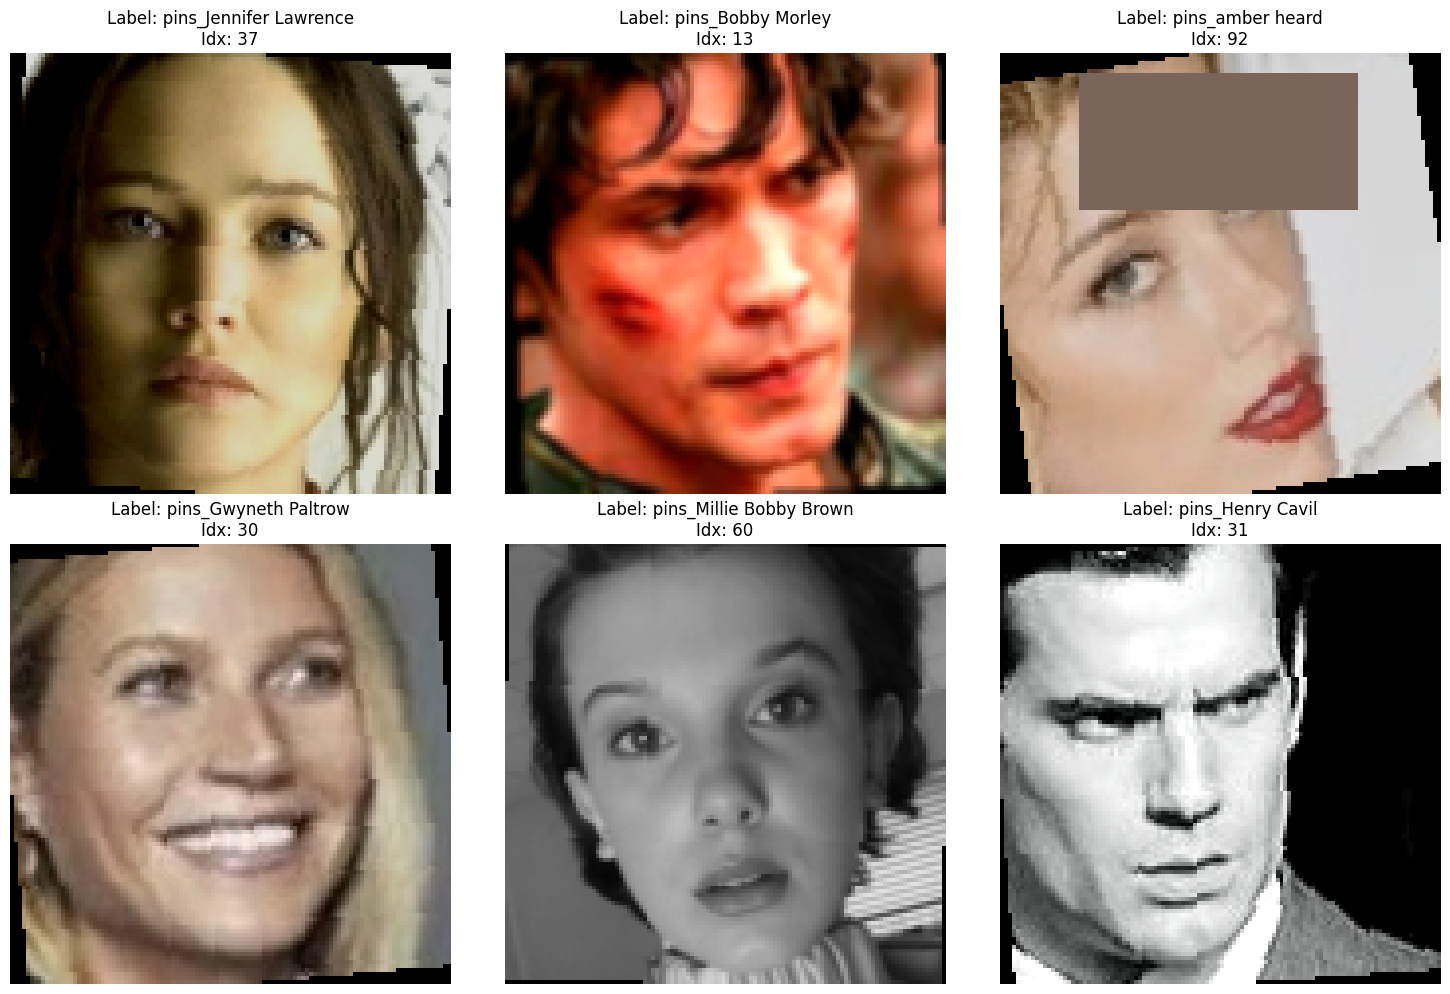

In [16]:
ds_iter = iter(train_loader)
ds_images, ds_labels = next(ds_iter)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

img_mean = np.array(mean)
img_std = np.array(std)

for i in range(6):
    image = ds_images[i].permute(1, 2, 0).cpu().numpy()
    label_idx = ds_labels[i].item()
    
    image = image * img_std + img_mean
    image = np.clip(image, 0, 1)
    
    axes[i].imshow(image)
    axes[i].set_title(f"Label: {class_names[label_idx]}\nIdx: {label_idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [17]:
def fit(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion,
    optimizer,
    folder: str,
    device,
    epochs=300,
    schedule=False,
):
    if schedule:
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=1e-7
        )
    os.makedirs(folder, exist_ok=True)

    history = []
    best_acc = 0
    best_loss = float("inf")

    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0

        train_pbar = tqdm(
            train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False
        )

        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total_correct += torch.sum(preds == labels.data)
            train_pbar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = total_loss / len(train_loader)
        train_acc = total_correct.double().item() / len(train_loader.dataset)

        model.eval()
        total_loss = 0.0
        total_correct = 0

        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

        with torch.no_grad():
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                total_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total_correct += torch.sum(preds == labels.data)
                val_pbar.set_postfix(v_loss=f"{loss.item():.4f}")

        val_loss = total_loss / len(val_loader)
        val_acc = total_correct.double().item() / len(val_loader.dataset)

        metrics = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(metrics)

        print(
            f"Epoch: {epoch+1} | T-loss: {train_loss} | V-loss: {val_loss} | T-acc: {train_acc} | V-acc: {val_acc} | lr: {optimizer.param_groups[0]["lr"]}"
        )

        if (epoch + 1) % 25 == 0:
            torch.save(model.state_dict(), os.path.join(folder, f"epoch_{epoch}.pth"))

        if val_loss < best_loss and val_acc > best_acc:
            best_acc = val_acc
            best_loss = val_loss
            torch.save(model.state_dict(), os.path.join(folder, f"best.pth"))
            print(f" --> Saved Best Model at Epoch {epoch+1}")

        if schedule:
            scheduler.step()

    torch.save(model.state_dict(), os.path.join(folder, f"last.pth"))
    pd.DataFrame(history).to_csv(os.path.join(folder, "history.csv"), index=False)

    return history

In [18]:
model = MyRecognitionModelV2(num_classes=len(ds.keys()))
summary(
    model,
    input_size=(1, 3, 112, 112),
)
model.to(device)

MyRecognitionModelV2(
  (block1): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (1): ConvBlock(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (1): ConvBlock(
      (conv): Conv2d

In [19]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

In [20]:
fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    folder=CHECKPOINTS_FOLDER,
    schedule=True
)

Epoch 1/300 [Train]:   0%|          | 0/111 [00:00<?, ?it/s]

Epoch: 1 | T-loss: 4.693063577016194 | V-loss: 4.506347292945499 | T-acc: 0.019192634560906516 | V-acc: 0.033474413235859944 | lr: 0.0001
 --> Saved Best Model at Epoch 1


Epoch: 2 | T-loss: 4.5551667728939575 | V-loss: 4.384527002062116 | T-acc: 0.029957507082152973 | V-acc: 0.057714505579068875 | lr: 9.999726120980734e-05
 --> Saved Best Model at Epoch 2


Epoch: 3 | T-loss: 4.384460462106241 | V-loss: 4.199328558785575 | T-acc: 0.04929178470254957 | V-acc: 0.07656791073489803 | lr: 9.998904513956854e-05
 --> Saved Best Model at Epoch 3


Epoch: 4 | T-loss: 4.194472491204202 | V-loss: 4.048903590156918 | T-acc: 0.07415014164305948 | V-acc: 0.113120430934975 | lr: 9.99753526902683e-05
 --> Saved Best Model at Epoch 4


...

Epoch: 297 | T-loss: 0.9149940373661282 | V-loss: 1.2114587284269787 | T-acc: 0.9978045325779037 | V-acc: 0.9442093112735668 | lr: 1.438146365620238e-07


Epoch: 298 | T-loss: 0.9151832090841757 | V-loss: 1.2076707510721116 | T-acc: 0.9971671388101983 | V-acc: 0.9442093112735668 | lr: 1.246473097317066e-07


Epoch: 299 | T-loss: 0.9197838150703155 | V-loss: 1.2094247511454992 | T-acc: 0.9963172804532577 | V-acc: 0.9445940746440938 | lr: 1.109548604314673e-07


Epoch: 300 | T-loss: 0.9178869885367316 | V-loss: 1.2065736282439459 | T-acc: 0.996600566572238 | V-acc: 0.9445940746440938 | lr: 1.0273879019266845e-07


[{'epoch': 1,
  'train_loss': 4.693063577016194,
  'train_acc': 0.019192634560906516,
  'val_loss': 4.506347292945499,
  'val_acc': 0.033474413235859944,
  'lr': 0.0001},
 {'epoch': 2,
  'train_loss': 4.5551667728939575,
  'train_acc': 0.029957507082152973,
  'val_loss': 4.384527002062116,
  'val_acc': 0.057714505579068875,
  'lr': 9.999726120980734e-05},
 {'epoch': 3,
  'train_loss': 4.384460462106241,
  'train_acc': 0.04929178470254957,
  'val_loss': 4.199328558785575,
  'val_acc': 0.07656791073489803,
  'lr': 9.998904513956854e-05},
 {'epoch': 4,
  'train_loss': 4.194472491204202,
  'train_acc': 0.07415014164305948,
  'val_loss': 4.048903590156918,
  'val_acc': 0.113120430934975,
  'lr': 9.99753526902683e-05},
 {'epoch': 5,
  'train_loss': 4.012400491817577,
  'train_acc': 0.1075070821529745,
  'val_loss': 3.8883375326792398,
  'val_acc': 0.13351288957291266,
  'lr': 9.995618536343798e-05},
 {'epoch': 6,
  'train_loss': 3.8068297704060874,
  'train_acc': 0.1495042492917847,
  'val_l

In [21]:
logs = pd.read_csv(os.path.join(CHECKPOINTS_FOLDER,"history.csv"))

In [22]:
def plot_history(history):
    if isinstance(history, list):
        epochs = [x['epoch'] for x in history]
        train_loss = [x['train_loss'] for x in history]
        val_loss = [x['val_loss'] for x in history]
        train_acc = [x['train_acc'] for x in history]
        val_acc = [x['val_acc'] for x in history]
        lr = [x.get('lr', 0) for x in history]
    else:

        epochs = history['epoch']
        train_loss = history['train_loss']
        val_loss = history['val_loss']
        train_acc = history['train_acc']
        val_acc = history['val_acc']
        lr = history['lr']
    
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_loss, 'r', label='Train Loss')
    plt.plot(epochs, val_loss, 'b', label='Val Loss')
    plt.title('Model loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_acc, 'g', label='Train Acc')
    plt.plot(epochs, val_acc, 'o-', label='Val Acc', markersize=3)
    plt.title('Model accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, lr, 'orange', label='lr')
    plt.title('Model learning rate')
    plt.xlabel('Epochs')
    plt.ylabel('Learning rate')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

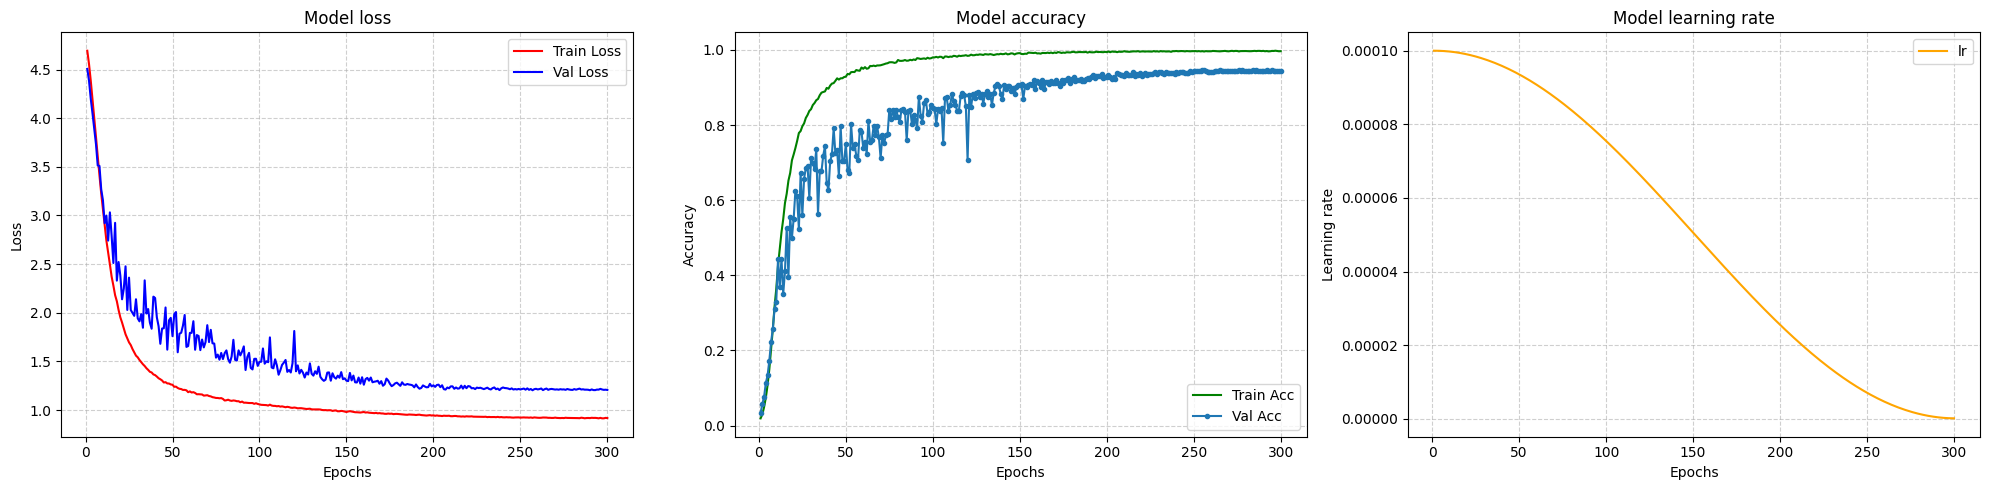

In [23]:
plot_history(logs)

In [24]:
# with open(os.path.join(CHECKPOINTS_FOLDER, "labels.txt"), "w", encoding="utf-8") as f:
#     for label in class_to_idx.keys():
#         f.write(f"{label}\n")